<a href="https://colab.research.google.com/github/dev-anju/ParkZen/blob/main/Copy_of_Testing_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -U ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 784.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.4 MB/s eta 0:00:00


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive/Parking_Project"))

['Cleaned_Dataset']


In [ ]:
dataset_path = "/content/drive/MyDrive/Parking_Project/Cleaned_Dataset"

print(os.listdir(dataset_path))

['valid', 'train', 'test', 'README.dataset.txt', 'README.roboflow.txt', 'data.yaml']


In [ ]:
yaml_content = """
path: /content/drive/MyDrive/Parking_Project/Cleaned_Dataset

train: train/images
val: valid/images
test: test/images

nc: 2

names:
  0: space-empty
  1: space-occupied
"""

yaml_path = "/content/drive/MyDrive/Parking_Project/Cleaned_Dataset/data.yaml"

with open(yaml_path, "w") as f:
    f.write(yaml_content)

print("data.yaml created successfully!")
print(yaml_path)

data.yaml created successfully!
/content/drive/MyDrive/Parking_Project/Cleaned_Dataset/data.yaml


In [ ]:
with open(yaml_path, "r") as f:
    print(f.read())


path: /content/drive/MyDrive/Parking_Project/Cleaned_Dataset

train: train/images
val: valid/images
test: test/images

nc: 2

names:
  0: space-empty
  1: space-occupied



In [ ]:
print(os.listdir("/content/drive/MyDrive/Parking_Project"))

['Cleaned_Dataset']


In [ ]:
from ultralytics import YOLO

print("Ultralytics installed successfully")

Ultralytics installed successfully


In [ ]:
yaml_content = """
path: /content/drive/MyDrive/Parking_Project/Cleaned_Dataset

train: train/images
val: valid/images
test: test/images

nc: 2

names:
  0: space-empty
  1: space-occupied
"""

yaml_path = "/content/drive/MyDrive/Parking_Project/Cleaned_Dataset/data.yaml"

with open(yaml_path, "w") as f:
    f.write(yaml_content)

print("data.yaml created!")

data.yaml created!


In [ ]:
with open(yaml_path, "r") as f:
    print(f.read())


path: /content/drive/MyDrive/Parking_Project/Cleaned_Dataset

train: train/images
val: valid/images
test: test/images

nc: 2

names:
  0: space-empty
  1: space-occupied



In [ ]:
import torch

print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

GPU available: True
GPU: Tesla T4


In [ ]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

results = model.train(
    data=yaml_path,
    epochs=50,
    imgsz=640,
    batch=16,
    project="/content/drive/MyDrive/Parking_Project/runs",
    name="parking_detection"
)

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.117 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Parking_Project/Cleaned_Dataset/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_

In [ ]:
import os

best_model = "/content/drive/MyDrive/Parking_Project/runs/parking_detection/weights/best.pt"

print("best.pt exists:", os.path.exists(best_model))

if os.path.exists(best_model):
    print("Size:", round(os.path.getsize(best_model) / (1024**2), 2), "MB")

In [ ]:
last_model = "/content/drive/MyDrive/Parking_Project/runs/parking_detection/weights/last.pt"

print("last.pt exists:", os.path.exists(last_model))

In [ ]:
from IPython.display import Image, display

display(Image(
    "/content/drive/MyDrive/Parking_Project/runs/parking_detection/results.png"
))

In [ ]:
from ultralytics import YOLO

model = YOLO(
    "/content/drive/MyDrive/Parking_Project/runs/parking_detection/weights/best.pt"
)

print("Model loaded successfully!")

In [ ]:
from ultralytics import YOLO

model = YOLO(
    "/content/drive/MyDrive/Parking_Project/runs/parking_detection/weights/best.pt"
)

metrics = model.val(
    data="/content/drive/MyDrive/Parking_Project/Cleaned_Dataset/data.yaml",
    split="test",
    imgsz=640,
    batch=16
)

In [ ]:
results = model.predict(
    source="/content/drive/MyDrive/Parking_Project/Cleaned_Dataset/test/images",
    imgsz=640,
    conf=0.25,
    save=True
)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

matches = []

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if file == "best.pt":
            matches.append(os.path.join(root, file))

print("Found best.pt files:")
for path in matches:
    print(path)

Found best.pt files:
/content/drive/MyDrive/Parking_Project/runs/parking_detection/weights/best.pt


In [ ]:
matches = []

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if file == "last.pt":
            matches.append(os.path.join(root, file))

print("Found last.pt files:")
for path in matches:
    print(path)

Found last.pt files:
/content/drive/MyDrive/Parking_Project/runs/parking_detection/weights/last.pt


In [ ]:
from ultralytics import YOLO

model_path = "/content/drive/MyDrive/Parking_Project/runs/parking_detection/weights/best.pt"

model = YOLO(model_path)

print("Model loaded successfully!")

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Model loaded successfully!


In [ ]:
metrics = model.val(
    data="/content/drive/MyDrive/Parking_Project/Cleaned_Dataset/data.yaml"
)

Ultralytics 8.4.117 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLO11n summary (fused): 101 layers, 2,582,542 parameters, 0 gradients, 6.4 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.7±0.1 ms, read: 0.1±0.0 MB/s, size: 70.0 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/drive/MyDrive/Parking_Project/Cleaned_Dataset/valid/labels.cache... 2483 images, 59 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2483/2483 297.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 156/156 5.5s/it 14:17
                   all       2483     143316      0.996      0.991      0.995      0.982
           space-empty       2062      73629      0.999      0.983      0.995      0.985
        space-occupied       1967      69687      0.993      0.999      0.994      0.979
Speed: 7.3ms preprocess, 

In [ ]:
import os

base = "/content/drive/MyDrive/Parking_Project/Cleaned_Dataset"

for split in ["train", "valid", "test"]:
    image_dir = os.path.join(base, split, "images")
    label_dir = os.path.join(base, split, "labels")

    images = os.listdir(image_dir) if os.path.exists(image_dir) else []
    labels = os.listdir(label_dir) if os.path.exists(label_dir) else []

    print("\n", split.upper())
    print("Images:", len(images))
    print("Labels:", len(labels))


 TRAIN
Images: 8653
Labels: 8653

 VALID
Images: 2483
Labels: 2483

 TEST
Images: 1242
Labels: 1242


In [ ]:
test_metrics = model.val(
    data="/content/drive/MyDrive/Parking_Project/Cleaned_Dataset/data.yaml",
    split="test"
)

Ultralytics 8.4.117 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
WARNING ⚠️ val: Slow image access detected (ping: 0.7±0.1 ms, read: 0.1±0.0 MB/s, size: 70.8 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/drive/MyDrive/Parking_Project/Cleaned_Dataset/test/labels... 1242 images, 26 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1242/1242 1.5it/s 14:13
val: New cache created: /content/drive/MyDrive/Parking_Project/Cleaned_Dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 78/78 4.8s/it 6:18
                   all       1242      70684      0.995      0.992      0.994      0.984
           space-empty       1041      36584      0.996      0.987      0.994      0.986
        space-occupied        991      34100      0.994      0.998      0.994      0.981
Speed: 7.7ms preprocess

In [ ]:
from ultralytics import YOLO

model = YOLO(
    "/content/drive/MyDrive/Parking_Project/runs/parking_detection/weights/best.pt"
)

print("Model loaded!")

Model loaded!


In [ ]:
import os
import random

test_images_path = "/content/drive/MyDrive/Parking_Project/Cleaned_Dataset/test/images"

images = os.listdir(test_images_path)

print("Number of test images:", len(images))

image_name = random.choice(images)
image_path = os.path.join(test_images_path, image_name)

print("Selected image:", image_path)

Number of test images: 1242
Selected image: /content/drive/MyDrive/Parking_Project/Cleaned_Dataset/test/images/2012-11-08_19_26_01_jpg.rf.42b8c0747c1b19b57b7e586c16a40596.jpg


In [ ]:
results = model.predict(
    source=image_path,
    conf=0.5,
    save=True
)


image 1/1 /content/drive/MyDrive/Parking_Project/Cleaned_Dataset/test/images/2012-11-08_19_26_01_jpg.rf.42b8c0747c1b19b57b7e586c16a40596.jpg: 640x640 1 space-empty, 99 space-occupieds, 194.8ms
Speed: 3.3ms preprocess, 194.8ms inference, 12.1ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


['/content/runs/detect/predict/2012-11-08_19_26_01_jpg.rf.42b8c0747c1b19b57b7e586c16a40596.jpg']


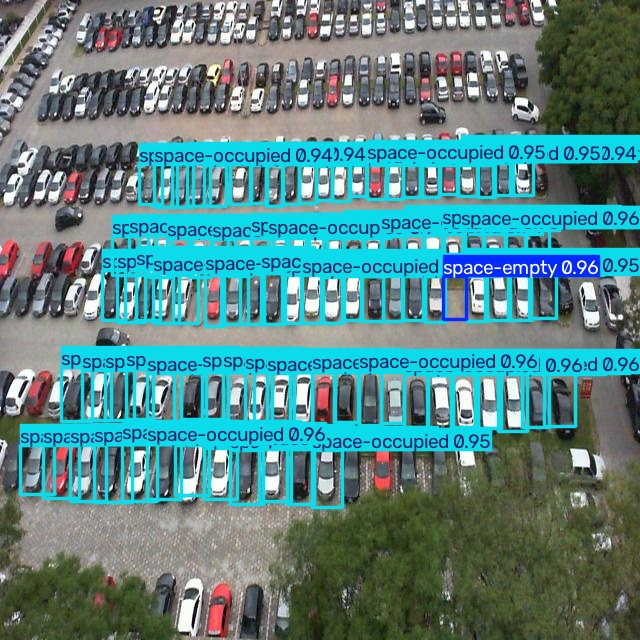

In [ ]:
from IPython.display import Image, display
import glob

predicted_files = glob.glob("/content/runs/detect/predict/*")

print(predicted_files)

display(Image(filename=predicted_files[0]))

In [ ]:
for result in results:
    print("Number of detections:", len(result.boxes))

    for box in result.boxes:
        class_id = int(box.cls[0])
        confidence = float(box.conf[0])

        class_name = model.names[class_id]

        print(
            f"{class_name}: {confidence:.2f}"
        )

Number of detections: 100
space-occupied: 0.96
space-occupied: 0.96
space-occupied: 0.96
space-occupied: 0.96
space-occupied: 0.96
space-empty: 0.96
space-occupied: 0.96
space-occupied: 0.96
space-occupied: 0.95
space-occupied: 0.95
space-occupied: 0.95
space-occupied: 0.95
space-occupied: 0.95
space-occupied: 0.95
space-occupied: 0.95
space-occupied: 0.95
space-occupied: 0.95
space-occupied: 0.95
space-occupied: 0.95
space-occupied: 0.95
space-occupied: 0.95
space-occupied: 0.95
space-occupied: 0.95
space-occupied: 0.95
space-occupied: 0.95
space-occupied: 0.95
space-occupied: 0.95
space-occupied: 0.95
space-occupied: 0.95
space-occupied: 0.95
space-occupied: 0.95
space-occupied: 0.95
space-occupied: 0.95
space-occupied: 0.95
space-occupied: 0.95
space-occupied: 0.95
space-occupied: 0.95
space-occupied: 0.94
space-occupied: 0.94
space-occupied: 0.94
space-occupied: 0.94
space-occupied: 0.94
space-occupied: 0.94
space-occupied: 0.94
space-occupied: 0.94
space-occupied: 0.94
space-occup

In [ ]:
empty = 0
occupied = 0

for result in results:
    for box in result.boxes:
        class_id = int(box.cls[0])
        class_name = model.names[class_id]

        if class_name == "space-empty":
            empty += 1
        elif class_name == "space-occupied":
            occupied += 1

print("Empty spaces:", empty)
print("Occupied spaces:", occupied)
print("Total detected:", empty + occupied)

Empty spaces: 1
Occupied spaces: 99
Total detected: 100


In [ ]:
import os
import random
from ultralytics import YOLO

test_dir = "/content/drive/MyDrive/Parking_Project/Cleaned_Dataset/test/images"

image_files = [
    os.path.join(test_dir, f)
    for f in os.listdir(test_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

# Select 10 random unseen test images
selected_images = random.sample(image_files, 10)

for i, image_path in enumerate(selected_images, 1):

    results = model.predict(
        source=image_path,
        conf=0.5,
        verbose=False
    )

    empty = 0
    occupied = 0

    for result in results:
        for box in result.boxes:
            class_id = int(box.cls[0])
            class_name = model.names[class_id]

            if class_name == "space-empty":
                empty += 1
            elif class_name == "space-occupied":
                occupied += 1

    print(f"\nImage {i}: {os.path.basename(image_path)}")
    print(f"Empty: {empty}")
    print(f"Occupied: {occupied}")
    print(f"Total: {empty + occupied}")


Image 1: 2013-04-13_17_45_13_jpg.rf.186e7a6b927c306bfcd445dd1a02ef85.jpg
Empty: 33
Occupied: 7
Total: 40

Image 2: 2013-01-19_19_50_16_jpg.rf.a5dc99d9c1dc2a49c2fbce09731c7c87.jpg
Empty: 28
Occupied: 0
Total: 28

Image 3: 2013-02-23_11_30_05_jpg.rf.09fb6af29b1ddc86eac9e6c56735dcb1.jpg
Empty: 28
Occupied: 12
Total: 40

Image 4: 2013-03-19_17_15_13_jpg.rf.6e49bb2a4ec740a8475a6f7911ef1584.jpg
Empty: 2
Occupied: 38
Total: 40

Image 5: 2012-10-26_11_39_41_jpg.rf.88504eb418890ff5c66eee80bbe37b5f.jpg
Empty: 12
Occupied: 88
Total: 100

Image 6: 2013-04-09_09_15_03_jpg.rf.8598661ded5366d19d13de2d672b0f67.jpg
Empty: 0
Occupied: 40
Total: 40

Image 7: 2013-04-11_06_25_00_jpg.rf.fde77b8ff9150e5e20c1b39f36b625d7.jpg
Empty: 39
Occupied: 1
Total: 40

Image 8: 2013-03-21_08_10_02_jpg.rf.593d3a9a5b104c643b555007ec361a8b.jpg
Empty: 8
Occupied: 32
Total: 40

Image 9: 2012-09-17_17_59_20_jpg.rf.018c0e89285f202f26dd49282bc598a6.jpg
Empty: 28
Occupied: 73
Total: 101

Image 10: 2012-12-11_18_56_11_jpg.rf.bd4

In [ ]:
image_path = "/content/drive/MyDrive/Parking_Project/Cleaned_Dataset/test/images/2012-09-17_17_59_20_jpg.rf.018c0e89285f202f26dd49282bc598a6.jpg"

results_9 = model.predict(
    source=image_path,
    conf=0.5,
    save=True
)

Results saved to /content/runs/detect/predict


Prediction files:
/content/runs/detect/predict/2012-11-08_19_26_01_jpg.rf.42b8c0747c1b19b57b7e586c16a40596.jpg
/content/runs/detect/predict/2012-09-17_17_59_20_jpg.rf.018c0e89285f202f26dd49282bc598a6.jpg


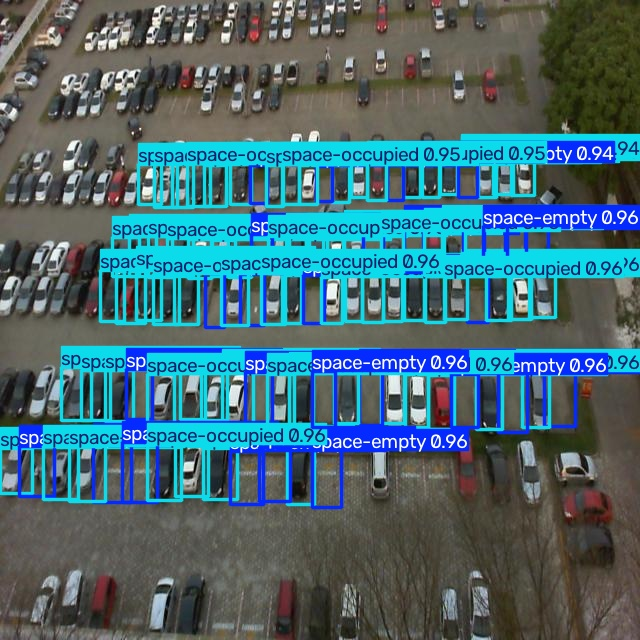

In [ ]:
from IPython.display import Image, display
import glob
import os

files = glob.glob("/content/runs/detect/predict/*")

print("Prediction files:")
for f in files:
    print(f)

# Find the Image 9 result
for f in files:
    if "2012-09-17_17_59_20" in os.path.basename(f):
        display(Image(filename=f))
        break

In [ ]:
import os

image_name = "2012-09-17_17_59_20_jpg.rf.018c0e89285f202f26dd492bc598a6.jpg"

label_path = os.path.join(
    "/content/drive/MyDrive/Parking_Project/Cleaned_Dataset/test/labels",
    image_name.rsplit(".", 1)[0] + ".txt"
)

print("Label file:", label_path)
print("Exists:", os.path.exists(label_path))

Label file: /content/drive/MyDrive/Parking_Project/Cleaned_Dataset/test/labels/2012-09-17_17_59_20_jpg.rf.018c0e89285f202f26dd492bc598a6.txt
Exists: False


In [ ]:
import os

label_dir = "/content/drive/MyDrive/Parking_Project/Cleaned_Dataset/test/labels"

files = os.listdir(label_dir)

matches = [
    f for f in files
    if "2012-09-17_17_59_20" in f
]

print("Matching label files:")
for f in matches:
    print(f)

Matching label files:
2012-09-17_17_59_20_jpg.rf.018c0e89285f202f26dd49282bc598a6.txt


In [ ]:
label_path = "/content/drive/MyDrive/Parking_Project/Cleaned_Dataset/test/labels/2012-09-17_17_59_20_jpg.rf.018c0e89285f202f26dd49282bc598a6.txt"

with open(label_path, "r") as f:
    labels = [line.strip() for line in f if line.strip()]

print("Ground-truth parking spaces:", len(labels))

empty_gt = 0
occupied_gt = 0

for label in labels:
    class_id = int(label.split()[0])

    if class_id == 0:
        empty_gt += 1
    elif class_id == 1:
        occupied_gt += 1

print("Ground-truth empty:", empty_gt)
print("Ground-truth occupied:", occupied_gt)

Ground-truth parking spaces: 100
Ground-truth empty: 28
Ground-truth occupied: 72


In [ ]:
import glob
import os

test_images = glob.glob(
    "/content/drive/MyDrive/Parking_Project/Cleaned_Dataset/test/images/*"
)

test_labels = glob.glob(
    "/content/drive/MyDrive/Parking_Project/Cleaned_Dataset/test/labels/*"
)

image_path = next(
    f for f in test_images
    if "2012-09-17_17_59_20" in os.path.basename(f)
)

label_path = next(
    f for f in test_labels
    if "2012-09-17_17_59_20" in os.path.basename(f)
)

print("Image:")
print(image_path)

print("\nLabel:")
print(label_path)

Image:
/content/drive/MyDrive/Parking_Project/Cleaned_Dataset/test/images/2012-09-17_17_59_20_jpg.rf.018c0e89285f202f26dd49282bc598a6.jpg

Label:
/content/drive/MyDrive/Parking_Project/Cleaned_Dataset/test/labels/2012-09-17_17_59_20_jpg.rf.018c0e89285f202f26dd49282bc598a6.txt


In [ ]:
import numpy as np

# Run prediction
results_9 = model.predict(
    source=image_path,
    conf=0.5,
    verbose=False
)

result = results_9[0]

# Predicted boxes and classes
pred_boxes = result.boxes.xyxy.cpu().numpy()
pred_classes = result.boxes.cls.cpu().numpy().astype(int)

# Read ground-truth labels
with open(label_path, "r") as f:
    labels = [line.strip() for line in f if line.strip()]

img_h, img_w = result.orig_shape

gt_boxes = []
gt_classes = []

for label in labels:
    parts = label.split()

    class_id = int(parts[0])
    x_center, y_center, width, height = map(float, parts[1:5])

    x_center *= img_w
    y_center *= img_h
    width *= img_w
    height *= img_h

    x1 = x_center - width / 2
    y1 = y_center - height / 2
    x2 = x_center + width / 2
    y2 = y_center + height / 2

    gt_boxes.append([x1, y1, x2, y2])
    gt_classes.append(class_id)

gt_boxes = np.array(gt_boxes)
gt_classes = np.array(gt_classes)


def calculate_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    intersection = max(0, x2 - x1) * max(0, y2 - y1)

    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])

    union = area1 + area2 - intersection

    return intersection / union if union > 0 else 0


# Match predictions with ground truth
matched_gt = set()
tp = 0

for i, pred_box in enumerate(pred_boxes):

    best_iou = 0
    best_gt = -1

    for j, gt_box in enumerate(gt_boxes):

        if j in matched_gt:
            continue

        if pred_classes[i] != gt_classes[j]:
            continue

        iou = calculate_iou(pred_box, gt_box)

        if iou > best_iou:
            best_iou = iou
            best_gt = j

    if best_iou >= 0.5:
        tp += 1
        matched_gt.add(best_gt)


fp = len(pred_boxes) - tp
fn = len(gt_boxes) - tp

precision = tp / (tp + fp) if (tp + fp) else 0
recall = tp / (tp + fn) if (tp + fn) else 0

print("\n===== IMAGE 9 EVALUATION =====")
print("Ground Truth:", len(gt_boxes))
print("Predictions :", len(pred_boxes))
print("True Positives :", tp)
print("False Positives:", fp)
print("False Negatives:", fn)
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))


===== IMAGE 9 EVALUATION =====
Ground Truth: 100
Predictions : 101
True Positives : 100
False Positives: 1
False Negatives: 0
Precision: 0.9901
Recall: 1.0


In [ ]:
import os

base = "/content/drive/MyDrive/Parking_Project"

for root, dirs, files in os.walk(base):
    for file in files:
        if file.lower().endswith((".mp4", ".avi", ".mov", ".mkv")):
            print(os.path.join(root, file))

/content/drive/MyDrive/Parking_Project/14706284_3840_2160_30fps.mp4


In [ ]:
from ultralytics import YOLO

model = YOLO(
    "/content/drive/MyDrive/Parking_Project/runs/parking_detection/weights/best.pt"
)

print("Model loaded successfully!")

Model loaded successfully!


In [ ]:
video_path = "/content/drive/MyDrive/Parking_Project/4196207-uhd_3840_2160_24fps.mp4"

results = model.predict(
    source=video_path,
    conf=0.5,
    imgsz=640,
    save=True,
    verbose=True
)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/373) /content/drive/MyDrive/Parking_Project/4196207-uhd_3840_2160_24fps.mp4: 384x640 (no detections), 236.4ms
video 1/1 (frame 2/373) /content/drive/MyDrive/Parking_Project/4196207-uhd_3840_2160_24fps.mp4: 384x640 (no detections), 145.1ms
video 1/1 (frame 3/373) /content/drive/MyDrive/Parking_Project/4196207-uhd_3840_2160_24fps.mp4: 384x640 (no detections), 165.3ms
video 1/1 (frame 4/373) /content/drive/MyDrive/Parking_Project/4196207-

In [ ]:
import glob
import os

files = glob.glob("/content/runs/detect/predict-2/*")

print("Output files:")
for f in files:
    print(f)

Output files:
/content/runs/detect/predict-2/14706284_3840_2160_30fps.avi


In [ ]:
import cv2
from ultralytics import YOLO
import os

# Load trained model
model = YOLO(
    "/content/drive/MyDrive/Parking_Project/runs/parking_detection/weights/best.pt"
)

input_video = "/content/drive/MyDrive/Parking_Project/4196207-uhd_3840_2160_24fps.mp4"

output_video = "/content/drive/MyDrive/Parking_Project/smart_parking_output_2.mp4"

cap = cv2.VideoCapture(input_video)

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print("FPS:", fps)
print("Resolution:", width, "x", height)

# Use MP4 output
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter(
    output_video,
    fourcc,
    fps,
    (width, height)
)

frame_count = 0

while True:

    ret, frame = cap.read()

    if not ret:
        break

    frame_count += 1

    # Run YOLO
    results = model.predict(
        source=frame,
        conf=0.5,
        imgsz=640,
        verbose=False
    )

    empty = 0
    occupied = 0

    # Count detections
    for result in results:

        for box in result.boxes:

            class_id = int(box.cls[0])
            class_name = model.names[class_id]

            if class_name == "space-empty":
                empty += 1

            elif class_name == "space-occupied":
                occupied += 1

    total = empty + occupied

    if total > 0:
        occupancy = (occupied / total) * 100
    else:
        occupancy = 0

    # Draw information panel
    cv2.rectangle(
        frame,
        (20, 20),
        (500, 190),
        (0, 0, 0),
        -1
    )

    cv2.putText(
        frame,
        "SMART PARKING SYSTEM",
        (40, 55),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (255, 255, 255),
        2
    )

    cv2.putText(
        frame,
        f"Total Spaces : {total}",
        (40, 95),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (255, 255, 255),
        2
    )

    cv2.putText(
        frame,
        f"Available    : {empty}",
        (40, 130),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (255, 255, 255),
        2
    )

    cv2.putText(
        frame,
        f"Occupied     : {occupied}",
        (40, 165),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (255, 255, 255),
        2
    )

    out.write(frame)

    if frame_count % 20 == 0:
        print(f"Processed {frame_count} frames")

cap.release()
out.release()

print("\nProcessing complete!")
print("Output saved to:")
print(output_video)

FPS: 24.0
Resolution: 3840 x 2160
Processed 20 frames
Processed 40 frames
Processed 60 frames
Processed 80 frames
Processed 100 frames
Processed 120 frames
Processed 140 frames
Processed 160 frames
Processed 180 frames
Processed 200 frames
Processed 220 frames
Processed 240 frames
Processed 260 frames
Processed 280 frames
Processed 300 frames
Processed 320 frames
Processed 340 frames
Processed 360 frames

Processing complete!
Output saved to:
/content/drive/MyDrive/Parking_Project/smart_parking_output_2.mp4


In [ ]:
import cv2

video_path = "/content/drive/MyDrive/Parking_Project/13072225_3840_2160_60fps.mp4"

cap = cv2.VideoCapture(video_path)

width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)

print("Width :", width)
print("Height:", height)
print("FPS   :", fps)

cap.release()

Width : 3840
Height: 2160
FPS   : 59.94005994005994


In [ ]:
import subprocess

print(subprocess.run(
    ["ffmpeg", "-version"],
    capture_output=True,
    text=True
).stdout.splitlines()[0])

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers


In [ ]:
import cv2
import subprocess
import os
from ultralytics import YOLO

# =========================
# PATHS
# =========================

model_path = "/content/drive/MyDrive/Parking_Project/runs/parking_detection/weights/best.pt"

input_video = "/content/drive/MyDrive/Parking_Project/13072225_3840_2160_60fps.mp4"

temp_video = "/content/parking_temp.mp4"

final_video = "/content/drive/MyDrive/Parking_Project/smart_parking_final_4K.mp4"


# =========================
# LOAD MODEL
# =========================

model = YOLO(model_path)

print("Model loaded successfully!")


# =========================
# OPEN ORIGINAL VIDEO
# =========================

cap = cv2.VideoCapture(input_video)

if not cap.isOpened():
    raise Exception("Could not open input video!")

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print("Resolution:", width, "x", height)
print("FPS:", fps)
print("Frames:", total_frames)


# =========================
# TEMP VIDEO
# =========================
# We use a lossless-ish intermediate format first.
# FFmpeg will create the final H.264 video later.

fourcc = cv2.VideoWriter_fourcc(*"MJPG")

out = cv2.VideoWriter(
    temp_video,
    fourcc,
    fps,
    (width, height)
)

frame_number = 0


# =========================
# PROCESS VIDEO
# =========================

while True:

    ret, frame = cap.read()

    if not ret:
        break

    frame_number += 1

    # YOLO inference
    results = model.predict(
        source=frame,
        conf=0.5,
        imgsz=640,
        verbose=False
    )

    result = results[0]

    # Draw bounding boxes
    annotated = result.plot(
        conf=False,
        labels=True,
        boxes=True
    )

    # Count spaces
    empty = 0
    occupied = 0

    for box in result.boxes:

        class_id = int(box.cls[0])
        class_name = model.names[class_id]

        if class_name == "space-empty":
            empty += 1

        elif class_name == "space-occupied":
            occupied += 1

    total = empty + occupied

    if total > 0:
        occupancy = occupied / total * 100
    else:
        occupancy = 0

    # =========================
    # INFORMATION PANEL
    # =========================

    panel_width = 600
    panel_height = 230

    overlay = annotated.copy()

    cv2.rectangle(
        overlay,
        (30, 30),
        (30 + panel_width, 30 + panel_height),
        (0, 0, 0),
        -1
    )

    # Slight transparency
    cv2.addWeighted(
        overlay,
        0.70,
        annotated,
        0.30,
        0,
        annotated
    )

    # Title
    cv2.putText(
        annotated,
        "SMART PARKING SYSTEM",
        (60, 75),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.1,
        (255, 255, 255),
        3
    )

    # Counts
    cv2.putText(
        annotated,
        f"Total Spaces : {total}",
        (60, 120),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.9,
        (255, 255, 255),
        2
    )

    cv2.putText(
        annotated,
        f"Available    : {empty}",
        (60, 160),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.9,
        (255, 255, 255),
        2
    )

    cv2.putText(
        annotated,
        f"Occupied     : {occupied}",
        (60, 200),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.9,
        (255, 255, 255),
        2
    )

    # =========================
    # WRITE FRAME
    # =========================

    out.write(annotated)

    if frame_number % 30 == 0:

        percent = frame_number / total_frames * 100

        print(
            f"Processed {frame_number}/{total_frames} "
            f"({percent:.1f}%) | "
            f"Empty: {empty} | "
            f"Occupied: {occupied}"
        )


cap.release()
out.release()

print("\nYOLO processing completed.")
print("Creating high-quality H.264 video...")


# =========================
# CONVERT TO H.264
# =========================

command = [
    "ffmpeg",
    "-y",
    "-i", temp_video,

    "-c:v", "libx264",

    # High quality
    "-crf", "18",

    # Good encoding preset
    "-preset", "medium",

    # Preserve frame rate
    "-r", str(fps),

    # Pixel format compatible with most players
    "-pix_fmt", "yuv420p",

    final_video
]

subprocess.run(command, check=True)


# =========================
# REMOVE TEMP FILE
# =========================

os.remove(temp_video)

print("\n======================================")
print("FINAL VIDEO CREATED SUCCESSFULLY!")
print("======================================")
print(final_video)

Model loaded successfully!
Resolution: 3840 x 2160
FPS: 59.94005994005994
Frames: 452
Processed 30/452 (6.6%) | Empty: 0 | Occupied: 0
Processed 60/452 (13.3%) | Empty: 0 | Occupied: 21
Processed 90/452 (19.9%) | Empty: 0 | Occupied: 9
Processed 120/452 (26.5%) | Empty: 0 | Occupied: 16
Processed 150/452 (33.2%) | Empty: 0 | Occupied: 14
Processed 180/452 (39.8%) | Empty: 1 | Occupied: 11
Processed 210/452 (46.5%) | Empty: 1 | Occupied: 8
Processed 240/452 (53.1%) | Empty: 0 | Occupied: 6
Processed 270/452 (59.7%) | Empty: 1 | Occupied: 5
Processed 300/452 (66.4%) | Empty: 0 | Occupied: 3
Processed 330/452 (73.0%) | Empty: 0 | Occupied: 4
Processed 360/452 (79.6%) | Empty: 0 | Occupied: 0
Processed 390/452 (86.3%) | Empty: 0 | Occupied: 0
Processed 420/452 (92.9%) | Empty: 0 | Occupied: 0
Processed 450/452 (99.6%) | Empty: 0 | Occupied: 0

YOLO processing completed.
Creating high-quality H.264 video...

FINAL VIDEO CREATED SUCCESSFULLY!
/content/drive/MyDrive/Parking_Project/smart_park

In [ ]:
import cv2
from ultralytics import YOLO

model = YOLO(
    "/content/drive/MyDrive/Parking_Project/runs/parking_detection/weights/best.pt"
)

video_path = "/content/drive/MyDrive/Parking_Project/13072225_3840_2160_60fps.mp4"

cap = cv2.VideoCapture(video_path)

# Get a frame around the middle
cap.set(cv2.CAP_PROP_POS_FRAMES, 200)

ret, frame = cap.read()

cap.release()

print("Frame loaded:", ret)
print("Frame size:", frame.shape)

Frame loaded: True
Frame size: (2160, 3840, 3)


In [ ]:
import cv2
import numpy as np
from ultralytics import YOLO

model = YOLO(
    "/content/drive/MyDrive/Parking_Project/runs/parking_detection/weights/best.pt"
)

# -----------------------------
# Frame already loaded above
# -----------------------------

h, w = frame.shape[:2]

# Divide the 4K frame into 6 overlapping tiles
tile_w = 1280
tile_h = 1080
overlap = 200

all_boxes = []
all_scores = []
all_classes = []

# -----------------------------
# Process tiles
# -----------------------------

for y in range(0, h, tile_h - overlap):

    for x in range(0, w, tile_w - overlap):

        x1 = x
        y1 = y

        x2 = min(x + tile_w, w)
        y2 = min(y + tile_h, h)

        tile = frame[y1:y2, x1:x2]

        # YOLO on tile
        results = model.predict(
            source=tile,
            conf=0.30,
            imgsz=640,
            verbose=False
        )

        result = results[0]

        # Convert tile coordinates back to original frame
        for box in result.boxes:

            bx1, by1, bx2, by2 = box.xyxy[0].cpu().numpy()

            bx1 += x1
            bx2 += x1
            by1 += y1
            by2 += y1

            score = float(box.conf[0])
            class_id = int(box.cls[0])

            all_boxes.append([bx1, by1, bx2, by2])
            all_scores.append(score)
            all_classes.append(class_id)


# -----------------------------
# Count detections
# -----------------------------

empty = 0
occupied = 0

for class_id in all_classes:

    class_name = model.names[class_id]

    if class_name == "space-empty":
        empty += 1

    elif class_name == "space-occupied":
        occupied += 1

print("================================")
print("TILED DETECTION RESULT")
print("================================")

print("Empty:", empty)
print("Occupied:", occupied)
print("Total:", empty + occupied)

TILED DETECTION RESULT
Empty: 3
Occupied: 44
Total: 47


In [ ]:
import cv2

input_video = "/content/drive/MyDrive/Parking_Project/13072225_3840_2160_60fps.mp4"

cap = cv2.VideoCapture(input_video)

width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)
frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print("Width :", width)
print("Height:", height)
print("FPS   :", fps)
print("Frames:", frames)
print("Duration:", frames / fps, "seconds")

# Grab a middle frame
cap.set(cv2.CAP_PROP_POS_FRAMES, frames // 2)

ret, frame = cap.read()

print("Frame loaded:", ret)

if ret:
    print("Frame shape:", frame.shape)

cap.release()

Width : 3840
Height: 2160
FPS   : 59.94005994005994
Frames: 452
Duration: 7.540866666666667 seconds
Frame loaded: True
Frame shape: (2160, 3840, 3)


In [ ]:
import cv2
import numpy as np
from ultralytics import YOLO

model = YOLO(
    "/content/drive/MyDrive/Parking_Project/runs/parking_detection/weights/best.pt"
)

# --------------------------------
# Use the same frame
# --------------------------------

h, w = frame.shape[:2]

tile_w = 1280
tile_h = 1080
overlap = 200

all_boxes = []
all_scores = []
all_classes = []

# --------------------------------
# TILED DETECTION
# --------------------------------

for y in range(0, h, tile_h - overlap):

    for x in range(0, w, tile_w - overlap):

        x1 = x
        y1 = y

        x2 = min(x + tile_w, w)
        y2 = min(y + tile_h, h)

        tile = frame[y1:y2, x1:x2]

        results = model.predict(
            source=tile,
            conf=0.30,
            imgsz=640,
            verbose=False
        )

        result = results[0]

        for box in result.boxes:

            bx1, by1, bx2, by2 = box.xyxy[0].cpu().numpy()

            # Convert tile coordinates → original frame
            bx1 += x1
            bx2 += x1
            by1 += y1
            by2 += y1

            all_boxes.append([bx1, by1, bx2, by2])
            all_scores.append(float(box.conf[0]))
            all_classes.append(int(box.cls[0]))


# --------------------------------
# NMS PER CLASS
# --------------------------------

final_boxes = []
final_scores = []
final_classes = []

for class_id in [0, 1]:

    indices = [
        i for i, c in enumerate(all_classes)
        if c == class_id
    ]

    if not indices:
        continue

    boxes_class = np.array(
        [all_boxes[i] for i in indices],
        dtype=np.float32
    )

    scores_class = [
        all_scores[i] for i in indices
    ]

    # OpenCV NMS expects xywh
    nms_boxes = []

    for box in boxes_class:

        x1, y1, x2, y2 = box

        nms_boxes.append([
            float(x1),
            float(y1),
            float(x2 - x1),
            float(y2 - y1)
        ])

    keep = cv2.dnn.NMSBoxes(
        nms_boxes,
        scores_class,
        score_threshold=0.30,
        nms_threshold=0.40
    )

    if len(keep) > 0:

        keep = np.array(keep).flatten()

        for k in keep:

            original_index = indices[k]

            final_boxes.append(
                all_boxes[original_index]
            )

            final_scores.append(
                all_scores[original_index]
            )

            final_classes.append(
                all_classes[original_index]
            )


# --------------------------------
# FINAL COUNTS
# --------------------------------

empty = sum(
    1 for c in final_classes
    if model.names[c] == "space-empty"
)

occupied = sum(
    1 for c in final_classes
    if model.names[c] == "space-occupied"
)

total = empty + occupied

print("================================")
print("AFTER NMS")
print("================================")

print("Empty:", empty)
print("Occupied:", occupied)
print("Total:", total)

AFTER NMS
Empty: 5
Occupied: 36
Total: 41


In [ ]:
import cv2
import numpy as np

# Create a copy of the original frame
annotated = frame.copy()

# Draw final NMS detections
for box, score, class_id in zip(
    final_boxes,
    final_scores,
    final_classes
):
    x1, y1, x2, y2 = map(int, box)

    class_name = model.names[class_id]

    # Label
    label = f"{class_name} {score:.2f}"

    # Draw box
    cv2.rectangle(
        annotated,
        (x1, y1),
        (x2, y2),
        (0, 255, 0),
        4
    )

    # Draw label
    cv2.putText(
        annotated,
        label,
        (x1, max(y1 - 10, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0, 255, 0),
        2
    )

# Save
test_output = "/content/drive/MyDrive/Parking_Project/tiled_test_frame.jpg"

cv2.imwrite(test_output, annotated)

print("Saved:")
print(test_output)

Saved:
/content/drive/MyDrive/Parking_Project/tiled_test_frame.jpg


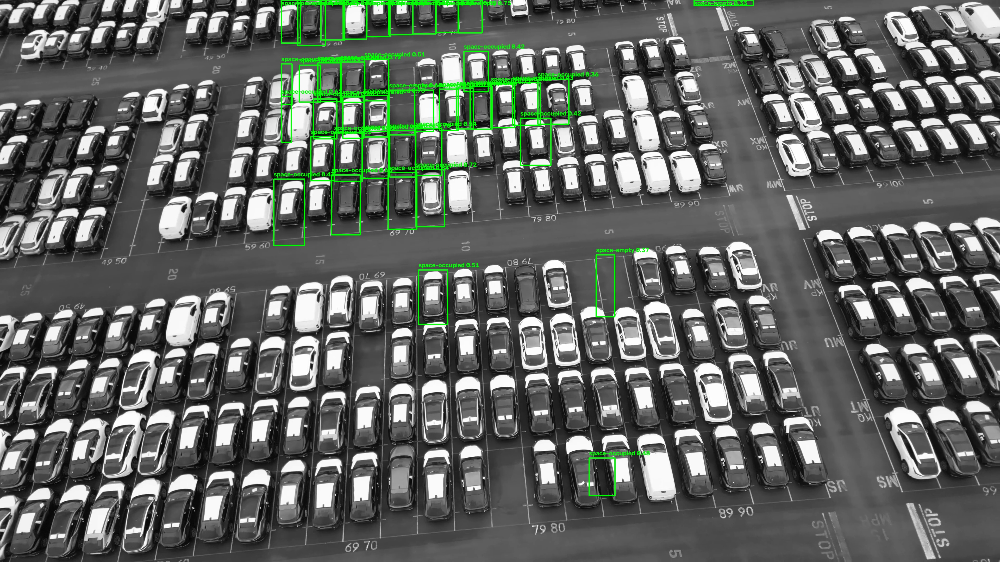

In [ ]:
from IPython.display import display
from PIL import Image

display(Image.open(test_output))